In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import tqdm
import copy
import numpy as np

In [2]:
from src.utils.normalizer import Normalizer
from typing import Optional, Tuple  

In [3]:
torch.FloatTensor

torch.FloatTensor

In [4]:
a = torch.empty((100,100))

b = torch.stack([torch.randperm(100) for _ in range(10)])

a[:,b].shape

torch.Size([100, 10, 100])

In [5]:
class Sparse(nn.Module):
    permutations0: torch.LongTensor
    permutations1: torch.LongTensor
    
    def __init__(self, original_weight: torch.Tensor, 
                 N:int = 2, 
                 M:int = 4,
                 n_permutations0:int = 10,
                 n_permutations1:int = 10,  
                 gamma: float = -0.1,
                 xi:float = 1.1) -> None:
        
        super(Sparse, self).__init__()
        
        # self.weight = nn.Parameter(original_weight.clone(), requires_grad=True)
        self.weight = nn.Parameter(torch.zeros_like(original_weight), requires_grad=True)
        self.sparse_mask = nn.Parameter(torch.zeros_like(original_weight), requires_grad=True)
        self.sparse_mask.data.uniform_(-1, 1)
        
        
        self.register_buffer("permutations0", torch.stack([torch.arange(original_weight.shape[0])] + [torch.randperm(original_weight.shape[0]) for _ in range(n_permutations0-1)])) 
        self.register_buffer("permutations1", torch.stack([torch.arange(original_weight.shape[1])] + [torch.randperm(original_weight.shape[1]) for _ in range(n_permutations1-1)]))

        
        self.permutation_scales0 = nn.Parameter(torch.randn(n_permutations0, original_weight.shape[0])/n_permutations0*np.sqrt(2), requires_grad=True)
        self.permutation_scales1 = nn.Parameter(torch.randn(n_permutations1, original_weight.shape[1])/n_permutations1*np.sqrt(2), requires_grad=True)
        
        
        self.N = N
        self.M = M
        self.gamma = gamma
        self.xi = xi
        # self.n_permutations = n_permutations
        
    def sigmoid(self, x: torch.Tensor) -> torch.Tensor:
        #scaled and clipped sigmoid function
        return torch.clip((self.xi-self.gamma) * torch.sigmoid(x) + self.gamma, 0, 1)
    
    def softmax(self, x: torch.Tensor) -> torch.Tensor:
        return F.softmax(x, dim=-1)
    
    def calculate_permutation_matrices(self) -> torch.Tensor:
        return self.softmax(self.permutation_matricies)
        
    def reconstruct_weight(self, sparse_weight: torch.Tensor) -> torch.Tensor:
        weight = torch.einsum("ijk,jk->ik",
                              sparse_weight[:, self.permutations1], #shape of (d_out, n_permutations, d_in)
                                self.permutation_scales1) #shape of (d_out, d_in)
        # print("Weight shape:", weight.shape)
        weight = torch.einsum("ijk,ij->jk",
                              weight[self.permutations0,:], #shape of (n_permutations, d_out, d_in)
                                self.permutation_scales0)
        # print("Weight shape:", weight.shape)
        return weight
    
    def forward(self) -> torch.Tensor:
        # Apply the sparse mask to the weight
        sparse_weight = self.weight * self.sigmoid(self.sparse_mask)
        
        return self.reconstruct_weight(sparse_weight)
    
    
    def binary_penalty_sparse(self, beta: float = 1.0) -> torch.Tensor:
        # Binary penalty for the sparse mask
        # print(torch.abs(2*self.sigmoid(self.permutation_matricies)-1))
        # print(torch.abs(2*self.sigmoid(self.sparse_mask)-1))
        # raise ValueError("Binary penalty is not implemented yet.")
        return torch.mean(1-torch.abs(2*self.sigmoid(self.sparse_mask)-1)**beta)
    
        
    
    def sparsity_penalty(self, l2: bool = True
                         ) -> torch.Tensor:
        # Sparsity penalty for the sparse mask
        if l2:
            return torch.sqrt(torch.mean(torch.square(torch.sum(self.sigmoid(self.sparse_mask).view(-1, self.M), dim=1) - self.N)))
        else:
            return torch.mean(torch.abs(torch.sum(self.sigmoid(self.sparse_mask).view(-1, self.M), dim=1) - self.N))
       
    @torch.no_grad() 
    def get_sparse_mask(self) -> torch.Tensor:
        sparse_mask_soft = self.sigmoid(self.sparse_mask)
        
        sparse_mask_hard = torch.zeros_like(sparse_mask_soft)
        
        #for each M elements in the sparse mask, set the top N elements to 1 and the rest to 0
        idxs = torch.argsort(sparse_mask_soft.view(-1, self.M), dim=1, descending=True)[:, :self.N]
        sparse_mask_hard = sparse_mask_hard.view(-1, self.M).scatter_(1, idxs, 1)
        return sparse_mask_hard.view_as(sparse_mask_soft)
    
    
    def real_weight(self)->torch.Tensor:
        #get the real weight matrix after applying the sparse mask and permutation matrices
        sparse_mask = self.get_sparse_mask()
        sparse_weight = self.weight * sparse_mask
        return self.reconstruct_weight(sparse_weight)
    
        
        
        
        
    
    
        
        

In [6]:
device = "cuda:7"

weight_path = "./models/meta-llama/Llama-2-7b-hf/original_weights/layer_0/mlp.up_proj.pt"
hessian_diag = weight_path.replace("original_weights", "hessianDiags/seed_0/pajama/128")


weight = torch.load(weight_path, map_location=device)["weight"].to(torch.float32).detach()
hessian_diag = torch.load(hessian_diag, map_location=device)["hessianDiag"].to(torch.float32    )

In [7]:
hessian_diag = torch.ones_like(hessian_diag)

In [8]:
with torch.no_grad():
    normalizer, normalized_weight = Normalizer.normalize_init(weight, norm_order=[0,1], zero = [False, False])
    normalized_weight = normalized_weight.to(device).detach()
  
#seed to 0 
torch.cuda.manual_seed_all(0)
np.random.seed(0)

S = Sparse(original_weight=normalized_weight.detach().clone(),
                    N=2, 
                    M=4,
                    n_permutations0=1,
                    n_permutations1=1,
                    gamma=-0.1,
                    xi=1.1).to(device)

print(S.real_weight())
# print(S.real_weight())

tensor([[0., -0., 0.,  ..., 0., -0., -0.],
        [0., -0., 0.,  ..., 0., -0., -0.],
        [-0., 0., -0.,  ..., -0., 0., 0.],
        ...,
        [0., -0., 0.,  ..., 0., -0., -0.],
        [0., -0., 0.,  ..., 0., -0., -0.],
        [-0., 0., -0.,  ..., -0., 0., 0.]], device='cuda:7',
       grad_fn=<ViewBackward0>)


In [9]:
normalized_weight.shape

torch.Size([11008, 4096])

In [10]:
1/c

NameError: name 'c' is not defined

In [12]:
with torch.no_grad():
    normalizer, normalized_weight = Normalizer.normalize_init(weight, norm_order=[0,1], zero = [False, False])
    normalized_weight = normalized_weight.to(device).detach()
  
#seed to 0 
torch.cuda.manual_seed_all(0)
np.random.seed(0)

S = Sparse(original_weight=normalized_weight.detach().clone(),
                    N=2, 
                    M=4,
                    n_permutations0=6,
                    n_permutations1=2,
                    gamma=-0.1,
                    xi=1.1).to(device)

optim = torch.optim.Adam(S.parameters(), lr=1e-1)
# lr_scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=500, gamma=0.1)   

n_iters = 1000

betas_sparse = np.linspace(4.0, 1.0, n_iters)
# betas_sparse = np.concat([np.linspace(3.0, 1.0, 3 * n_iters//4),
                        #   np.linspace(1.0, 1.5, n_iters//4)])
# raise ValueError("betas_sparse:", betas_sparse)

# print("betas_permutation:", betas_permutation)
# raise ValueError("betas_sparse:", betas_sparse)
lambda_binary_sparse, lambda_sparsity = 1,1
recon_loss_scaling = 1.0
c = torch.mean(normalized_weight ** 2 * hessian_diag.unsqueeze(0))

l = []
for i in tqdm.tqdm(range(n_iters)):
    
    optim.zero_grad()
    
    # Forward pass
    if torch.rand(1).item() < 0.25:
        sparse_weight = S()
    else:
        sparse_weight = S.real_weight()
    
    # print("beta:", betas[i])
    sparse_binary = S.binary_penalty_sparse(beta=betas_sparse[i])
    
    sparsity_penalty = S.sparsity_penalty(l2=False)
    
    # Compute the loss
    recon_loss = torch.mean((sparse_weight - normalized_weight) ** 2 * hessian_diag.unsqueeze(0))/c
    # loss = binary_penalty * lambda_binary 
    loss = (sparse_binary * lambda_binary_sparse +
            sparsity_penalty * lambda_sparsity) + recon_loss*recon_loss_scaling
    
    # loss = recon_loss*recon_loss_scaling
    
    # Backward pass
    loss.backward()
    optim.step()
    # lr_scheduler.step()
    if i % 10 == 0:
      real_reconstruction = S.real_weight()
      real_reconstruction_loss = torch.mean((real_reconstruction - normalized_weight) ** 2 * hessian_diag.unsqueeze(0))/c
      print(f"Iteration {i}, Loss: {loss.item()}, "
            f"Sparse Binary Penalty: {sparse_binary.item()}, "
            # f"Permutation Binary Penalty: {permutation_binary.item()}, "
            f"Sparsity Penalty: {sparsity_penalty.item()}, "
            # f"Permutation Penalty: {permutation_penalty.item()}, "
            f"Reconstruction Loss: {recon_loss.item()}, "
            f"Real Reconstruction Loss: {real_reconstruction_loss.item()}"
                )
    # l.append(real_reconstruction_loss.item())
    
    

  1%|          | 8/1000 [00:00<00:37, 26.27it/s]

Iteration 0, Loss: 2.246473789215088, Sparse Binary Penalty: 0.9793197512626648, Sparsity Penalty: 0.26715391874313354, Reconstruction Loss: 1.0, Real Reconstruction Loss: 8.360475540161133


  2%|▏         | 18/1000 [00:01<01:40,  9.73it/s]

Iteration 10, Loss: 2.107273578643799, Sparse Binary Penalty: 0.9785252809524536, Sparsity Penalty: 0.07525228708982468, Reconstruction Loss: 1.0534958839416504, Real Reconstruction Loss: 1.0456591844558716


  3%|▎         | 28/1000 [00:03<01:54,  8.52it/s]

...

 99%|█████████▉| 988/1000 [02:35<00:01,  7.85it/s]

Iteration 980, Loss: 0.4015491306781769, Sparse Binary Penalty: 9.525709901936352e-05, Sparsity Penalty: 0.00012704601977020502, Reconstruction Loss: 0.40132683515548706, Real Reconstruction Loss: 0.4053076207637787


100%|█████████▉| 998/1000 [02:37<00:00,  7.80it/s]

Iteration 990, Loss: 0.4053977429866791, Sparse Binary Penalty: 7.920392818050459e-05, Sparsity Penalty: 0.00010811653191922233, Reconstruction Loss: 0.4052104353904724, Real Reconstruction Loss: 0.4052249789237976


100%|██████████| 1000/1000 [02:37<00:00,  6.35it/s]


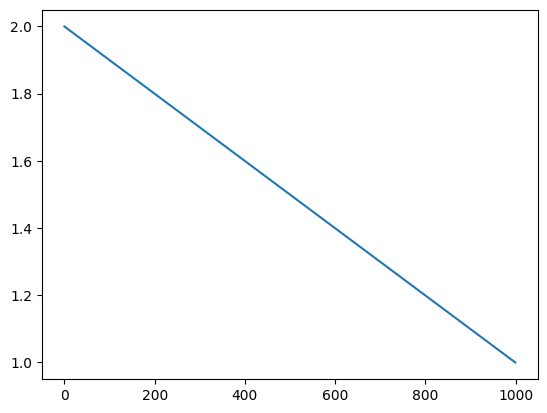

In [156]:
import matplotlib.pyplot as plt
plt.plot(betas_sparse)


In [157]:
S.sigmoid(S.sparse_mask).view(-1, S.M)

tensor([[1., 0., 0., 1.],
        [1., 1., 0., 0.],
        [1., 0., 0., 1.],
        ...,
        [1., 0., 1., 0.],
        [1., 1., 0., 0.],
        [1., 1., 0., 0.]], device='cuda:7', grad_fn=<ViewBackward0>)

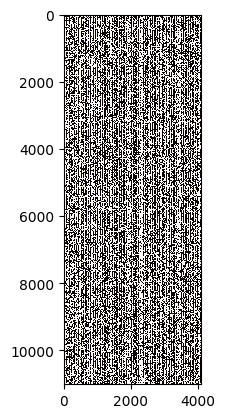

In [158]:
import matplotlib.pyplot as plt
plt.imshow(S.sigmoid(S.sparse_mask).detach().cpu().numpy(), cmap='hot', interpolation='nearest')


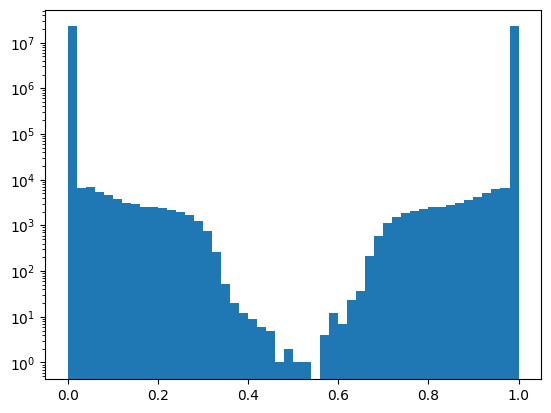

In [159]:
plt.hist(S.sigmoid(S.sparse_mask).detach().cpu().numpy().flatten(), bins=50)
plt.yscale('log')

In [160]:
F.mse_loss(S(),S.real_weight())

tensor(1.2978e-07, device='cuda:7', grad_fn=<MseLossBackward0>)

In [161]:
S.real_weight()

tensor([[-3.5497e-03, -1.1681e-02,  9.0338e-03,  ..., -6.2273e-03,
          3.4528e-03, -6.8702e-03],
        [-1.2952e-03,  2.0989e-03,  1.1268e-02,  ...,  2.9698e-03,
          2.1569e-03, -1.2679e-02],
        [-8.3916e-03, -2.0726e-03, -9.3851e-03,  ..., -5.2781e-03,
          1.6303e-03,  1.7992e-03],
        ...,
        [-5.4704e-04,  6.5672e-03, -6.1143e-03,  ...,  4.2179e-03,
         -1.3626e-03,  1.7631e-03],
        [ 1.1502e-03,  1.3355e-02,  1.8115e-02,  ...,  5.0269e-03,
         -1.4388e-02,  5.9803e-03],
        [-5.9093e-03,  9.5465e-03, -6.4252e-05,  ...,  9.1613e-03,
          1.3089e-03, -9.6911e-03]], device='cuda:7', grad_fn=<ViewBackward0>)

In [162]:
normalized_weight

tensor([[ 0.0003, -0.0279,  0.0138,  ..., -0.0194, -0.0250,  0.0062],
        [-0.0107, -0.0307,  0.0122,  ...,  0.0181,  0.0058,  0.0024],
        [-0.0056,  0.0144, -0.0079,  ..., -0.0212,  0.0070,  0.0017],
        ...,
        [-0.0090, -0.0017, -0.0066,  ...,  0.0289, -0.0028,  0.0182],
        [-0.0167,  0.0075,  0.0189,  ...,  0.0014, -0.0165,  0.0032],
        [ 0.0188,  0.0197, -0.0004,  ...,  0.0115, -0.0140, -0.0383]],
       device='cuda:7')

In [163]:
#try just standard naive pruning
importances = normalized_weight**2 * hessian_diag.unsqueeze(0)
# torch.abs(weight)  # Example importance scores based on absolute values of weights

idxs = torch.argsort(importances.view(-1, S.M), dim=1, descending=True)[:, :S.N]
sparse_mask_hard = torch.zeros_like(importances)
sparse_mask_hard = sparse_mask_hard.view(-1, S.M).scatter_(1, idxs, 1)
sparse_mask_hard = sparse_mask_hard.view_as(importances)
# Apply the sparse mask to the weight
sparse_weight = normalized_weight * sparse_mask_hard

#get the mse
recon_loss_naive = torch.mean((sparse_weight - normalized_weight) ** 2 * hessian_diag.unsqueeze(0))/c
print(f"Naive Reconstruction Loss: {recon_loss_naive.item()}")

Naive Reconstruction Loss: 0.0892343744635582


In [164]:
print("our method reconstruction loss:", recon_loss.item())

our method reconstruction loss: 0.2976599335670471


In [165]:
sparse_weight

tensor([[ 0.0000, -0.0279,  0.0138,  ..., -0.0000, -0.0250,  0.0000],
        [-0.0000, -0.0307,  0.0000,  ...,  0.0181,  0.0000,  0.0000],
        [-0.0000,  0.0144, -0.0079,  ..., -0.0212,  0.0000,  0.0000],
        ...,
        [-0.0090, -0.0000, -0.0066,  ...,  0.0289, -0.0000,  0.0000],
        [-0.0000,  0.0000,  0.0189,  ...,  0.0000, -0.0165,  0.0000],
        [ 0.0000,  0.0197, -0.0000,  ...,  0.0000, -0.0140, -0.0383]],
       device='cuda:7')

In [166]:
S.real_weight()

tensor([[-3.5497e-03, -1.1681e-02,  9.0338e-03,  ..., -6.2273e-03,
          3.4528e-03, -6.8702e-03],
        [-1.2952e-03,  2.0989e-03,  1.1268e-02,  ...,  2.9698e-03,
          2.1569e-03, -1.2679e-02],
        [-8.3916e-03, -2.0726e-03, -9.3851e-03,  ..., -5.2781e-03,
          1.6303e-03,  1.7992e-03],
        ...,
        [-5.4704e-04,  6.5672e-03, -6.1143e-03,  ...,  4.2179e-03,
         -1.3626e-03,  1.7631e-03],
        [ 1.1502e-03,  1.3355e-02,  1.8115e-02,  ...,  5.0269e-03,
         -1.4388e-02,  5.9803e-03],
        [-5.9093e-03,  9.5465e-03, -6.4252e-05,  ...,  9.1613e-03,
          1.3089e-03, -9.6911e-03]], device='cuda:7', grad_fn=<ViewBackward0>)

In [167]:
normalized_weight

tensor([[ 0.0003, -0.0279,  0.0138,  ..., -0.0194, -0.0250,  0.0062],
        [-0.0107, -0.0307,  0.0122,  ...,  0.0181,  0.0058,  0.0024],
        [-0.0056,  0.0144, -0.0079,  ..., -0.0212,  0.0070,  0.0017],
        ...,
        [-0.0090, -0.0017, -0.0066,  ...,  0.0289, -0.0028,  0.0182],
        [-0.0167,  0.0075,  0.0189,  ...,  0.0014, -0.0165,  0.0032],
        [ 0.0188,  0.0197, -0.0004,  ...,  0.0115, -0.0140, -0.0383]],
       device='cuda:7')